# ERM with Real + Generated Data, Pruning, and Super-Label $u=(\varepsilon, y)$

This notebook demonstrates how to **predict** and **empirically verify** the high-dimensional asymptotics of an ERM trained on a mixture of:

- **real data** (weight $\varepsilon=1$),
- **generated data** (weight $\varepsilon=\varepsilon(x,y)\in[0,1]$ given by a pruning/curation rule),

using the *super-label* formalism:
\[
u = (\varepsilon, y),\qquad L_u(z) = \varepsilon\,\ell_y(z).
\]


In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt

# Make sure /mnt/data is on the import path
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

# --- Core models / theory ---
from data_models import TeacherStudentModel
from data_models_pruning import RealGeneratedPrunedModel, OracleMarginPruner, unit, make_aligned_vector
from losses_regularizers import (
    SquaredLoss, LogisticLoss, HingeLoss,
    EpsScaledLoss,
    QuadraticRegularizer,
)
from erm_theory import ERMTrainer, TheoryFixedPointSolver


In [30]:
# -----------------------
# Problem configuration
# -----------------------
rng = np.random.default_rng(0)

p = 80
n_train = 200          # total training samples
gamma_r = 0.1          # fraction real (gamma_g = 0.4)
rho = 1             # generator alignment with truth
rho_o = 1             # generator alignment with truth
lambda_gen = 2.0       # scales eps on generated samples

ridge = 2.0            # ridge strength in QuadraticRegularizer

# Real / generator feature covariances (covariate shift can be tested)
Sigma_r = np.eye(p)
Sigma_g = np.eye(p)

# Teacher direction (truth)
w_star = unit(rng.standard_normal(size=p))
# Generator direction with alignment rho
w_g = make_aligned_vector(w_star, rho=rho, rng=rng)
# Oracle direction (can be made imperfect if desired)
w_o = make_aligned_vector(w_star, rho=rho_o, rng=rng)

# Build real and generated data models (binary classification: y = sign(x^T w))
mu_x = np.zeros(p)
mu_x[0] = 3

real_model = TeacherStudentModel(
    p=p, mu_x=mu_x, C_x=Sigma_r, feature_dist="gaussian",
    theta_teacher=w_star, y_model="sign", noise_std=0.0,
)

gen_model = TeacherStudentModel(
    p=p, mu_x=mu_x, C_x=Sigma_g, feature_dist="gaussian",
    theta_teacher=w_g, y_model="sign", noise_std=0.0,
)
models = {'Real data': real_model, 'Generated data': gen_model}
# (x, y, epsi)

# L_{y,eps}(x) = eps l_y(x)

# Choose base loss (switchable)
base_loss = LogisticLoss()   # or SquaredLoss(), HingeLoss()
loss = EpsScaledLoss(base_loss=base_loss)

# Ridge regularizer
reg = QuadraticRegularizer(a=np.zeros(p), H=ridge * np.eye(p))

# print("Combined model num_classes:", mix_model.num_classes)
# print("Class mixture gamma:", mix_model.class_params()["gamma"])


In [34]:
nb_points = 10
deltas = np.linspace(0, 2, nb_points)
ratio_th_emp = 3
nb_points_th = ratio_th_emp*(nb_points-1)+1
deltas_th = np.linspace(0, 2, nb_points_th)
rng = np.random.default_rng(1)
fp_damping =0.1
fp_tol = 2e-5
fp_max_iter = 1000
mc_samples = 10000
num_trials = 80
n_test = 10000

vars = {'Mixed data': {}}
for key in vars.keys():
    vars[key] = {
        'error_emp_means': [], 'error_emp_stds': [], 'error_classif_emp': [],
        'error_th': [], 'error_gaussian_score': [], 'error_classif_th': [],
        'nu': [],'mu': [], 'kappa': [], 'alpha': [],
    }
var_fixed_pt = ['mu', 'nu', 'kappa', 'alpha']
thetas_rcrd = dict()
for (idx,delta) in enumerate(deltas_th):
    # loss = ElasticL1L2Loss(lam)
    # Pruner: label-aware oracle-margin rule with threshold delta
    pruner = OracleMarginPruner(w_oracle=w_o, delta=delta, label_aware=True, soft=False)

    # Combined model (returns u=(eps,y))
    models['Mixed data'] = RealGeneratedPrunedModel(
        real_model=models['Real data'],
        gen_model=models['Generated data'],
        pruner=pruner,
        gamma_r=gamma_r,
        lambda_gen=lambda_gen,
    )
    K = models['Mixed data'].class_params()['num_classes']
    if idx%ratio_th_emp ==0:
        
        print(f"\n===== delta = {delta:g} (empirical gen reg) =====")
        for model_name in ['Mixed data']:
            model = models[model_name]
            trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
            emp = trainer.run_trials(
                n_train=n_train,
                n_test=n_test,
                num_trials=num_trials,
                rng=rng,
                solver_maxiter=2000,
                tol=1e-6,
                method="L-BFGS-B",
                verbose=False,
            )
            # if idx==0 or idx ==nb_points-1:
            thetas_rcrd[(model_name, idx)] = trainer.thetas
            vars[model_name]['error_emp_means'].append(emp["gen_loss_mean"])
            vars[model_name]['error_emp_stds'].append(emp["gen_loss_std"])
            vars[model_name]['error_classif_emp'].append(model.error_classif_emp(thetas_rcrd[(model_name, idx)], n_test=n_test))
            
            print(f"Empirical loss for {model_name}: mean={emp['gen_loss_mean']:.6f}  std={emp['gen_loss_std']:.6f} class. loss: {vars[model_name]['error_classif_emp'][-1]:.6f}")


    print(f"\n===== delta = {delta:g} (theory) =====")
    for model_name in ['Mixed data']:
        model = models[model_name]
        solver = TheoryFixedPointSolver(
            model=model,
            loss=loss,
            regularizer=reg,
            n_train=n_train,
            mc_samples=mc_samples,  # more samples for smaller etabda
            rng=np.random.default_rng(123),  # fixed for repeatability
        )

        th = solver.solve(
            max_iter=fp_max_iter,
            tol= fp_tol,
            damping= fp_damping,
            verbose=False,
            mu0=vars[model_name]['mu'][-1] if idx>0 else None,
            alpha0=[vars[model_name]['alpha'][-1][cl] for cl in range(K)] if idx>0 else None,
            nu0=[1/(1+vars[model_name]['kappa'][-1][cl]) for cl in range(K)] if idx>0 else None,
        )

        vars[model_name]['error_th'].append(th["predicted_loss"])
        vars[model_name]['error_classif_th'].append(model.error_classif_th(th["mu"], th["alpha"], num_trials=100000))

        # Warm start for next etabda
        for var in var_fixed_pt:
            vars[model_name][var].append(th[var])
        print(f"Theory predicted loss for {model_name} model: {th['predicted_loss']:.6f} class. loss: {vars[model_name]['error_classif_th'][-1]:.6f}  (converged={th['converged']}, iters={th['num_iter']}, damping_final={th.get('damping_final', float('nan')):.3f})")
        
        


===== delta = 0 (empirical gen reg) =====


Empirical loss for Mixed data: mean=1.128171  std=0.008433 class. loss: 0.559510

===== delta = 0 (theory) =====
Theory predicted loss for Mixed data model: 1.124211 class. loss: 0.528548  (converged=False, iters=1000, damping_final=0.003)

===== delta = 0.0740741 (theory) =====
Theory predicted loss for Mixed data model: 1.053234 class. loss: 0.539812  (converged=False, iters=1000, damping_final=0.003)

===== delta = 0.148148 (theory) =====
Theory predicted loss for Mixed data model: 0.981126 class. loss: 0.537176  (converged=False, iters=1000, damping_final=0.003)

===== delta = 0.222222 (empirical gen reg) =====
Empirical loss for Mixed data: mean=0.916017  std=0.010021 class. loss: 0.558204

===== delta = 0.222222 (theory) =====
Theory predicted loss for Mixed data model: 0.912299 class. loss: 0.538712  (converged=False, iters=1000, damping_final=0.003)

===== delta = 0.296296 (theory) =====
Theory predicted loss for Mixed data model: 0.848278 class. loss: 0.536681  (converged=Fals

In [40]:
K

2

In [42]:
num_trials_th = 100000
scores_emp = dict()
scores_th = dict()
rngz = np.random.default_rng()
rngtst = np.random.default_rng()
z_samples = rngz.standard_normal(size=num_trials_th) 
for c_label in range(K):
    for idx in [0,nb_points-1]:
        for model_name in ['Mixed data']:
            theta_star = models[model_name].class_params()['w_values']
            sc_emp=[]
            for i in range(num_trials):
                Xte, ute = models[model_name].sample_class(c_label, n_test, rng=rngtst)
                # eps, yte = self._split_u(ute)
                # sc_emp += [Xte[j]@thetas_rcrd[(model_name, idx)][i] for j in range(n_test)]
                sc_emp += [Xte[j]@(thetas_rcrd[(model_name, idx)][i]-theta_star[c_label]) for j in range(n_test)]
            scores_emp[(model_name, idx)] = np.array(sc_emp)
            Xtst, utst = models[model_name].sample_class(c_label,num_trials_th, rng=rngtst)
            # epstst, ytst = self._split_u(utst)
            idx_th = ratio_th_emp*(idx-1)
            # scores_th[(model_name, idx)] = Xtst@vars[model_name]["mu"][ratio_th_emp*(idx-1)] + vars[model_name]["alpha"][ratio_th_emp*(idx-1)][c_label]*z_samples
            scores_th[(model_name, idx)] = Xtst@(vars[model_name]["mu"][idx_th]-theta_star[c_label]) + vars[model_name]["alpha"][idx_th][c_label]*z_samples

In [44]:
vars[model_name]["alpha"][idx_th]

array([0.08141042, 0.08141042])

/tmp/ipykernel_24704/4128697497.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Gene

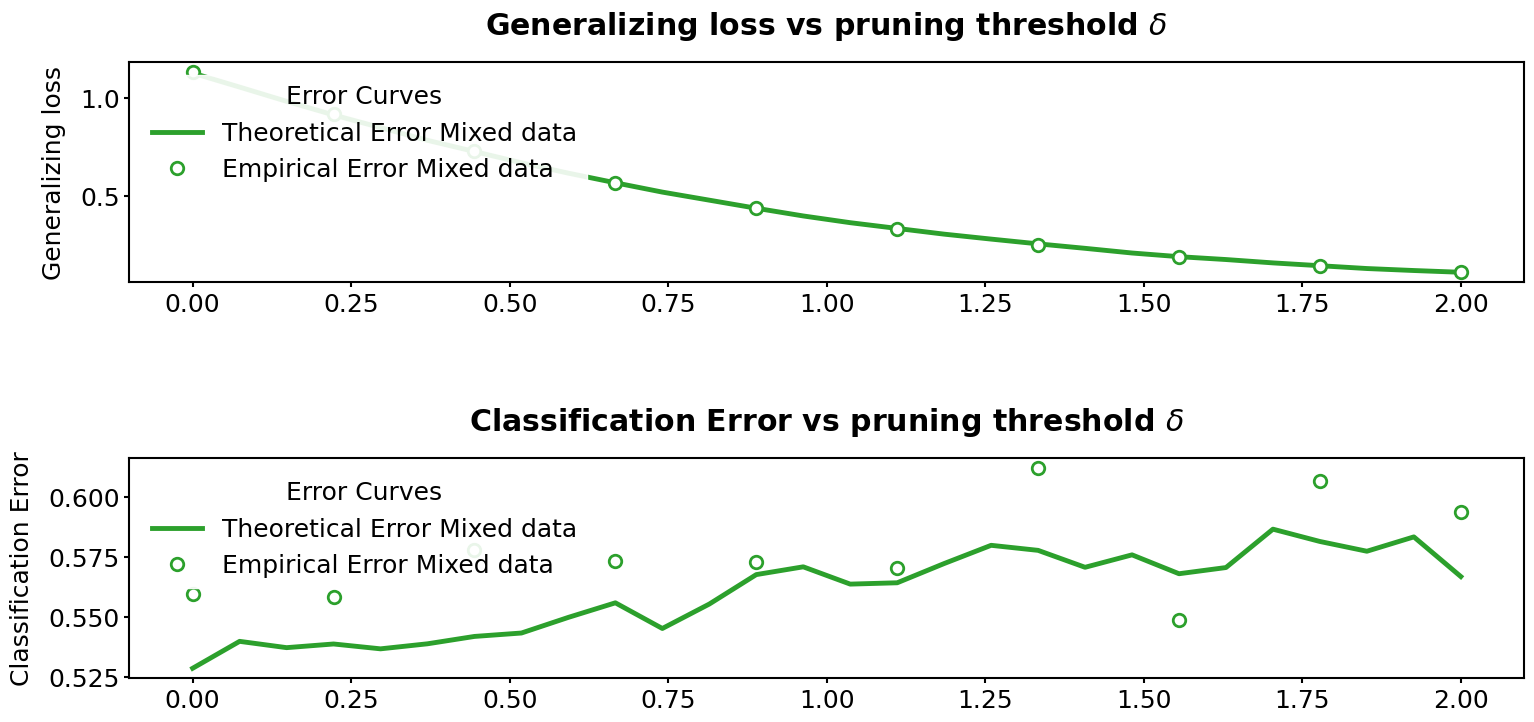

In [47]:

# --- Reset font settings for a modern, clean look ---
from matplotlib import patheffects
from sklearn.neighbors import KernelDensity
from scipy.stats import norm
from matplotlib.gridspec import GridSpec

plt.rcParams['text.usetex'] = False
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
# findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica

colors = {
    'Mixed data':{
        'raw_score': '#2CA02C',
        'score_univ': "#97B33C",
    },
}


fig = plt.figure(figsize=(18, 8))

gs = GridSpec(
    nrows=2,
    ncols=1,
    # height_ratios=[1, 1],  # adjust if needed
    # width_ratios=[1, 2],  # adjust if needed
    hspace=0.8,
    wspace=0.3
)

# model_names = ['Mixed data']
# axes_histo = {0: {'Mixed data' : fig.add_subplot(gs[0, 0])},
#               nb_points -1: {'Mixed data' : fig.add_subplot(gs[1, 0])}}

ax_mid = fig.add_subplot(gs[0, 0])
ax_mid_low = fig.add_subplot(gs[1,0])

# Bottom: spans both columns
# --- LEFT PANEL: Histograms + PDFs ---
# for c_label in classes:
c_label=0
alpha = {'Mixed data':0.6,'Gaussian data':0.2}
# for idx_delta in [0,nb_points -1]:
#     for model_name in model_names:
#         axes_histo[idx_delta][model_name].hist(
#             scores_emp[(model_name, idx_delta)],
#             bins=30,
#             density=True,
#             alpha=alpha[model_name],
#             color=colors[model_name]['raw_score'],
#             edgecolor='white',
#             linewidth=2,
#             label=f'{model_name} score' 
#         )
#         scth = scores_th[(model_name, idx_delta)]
#         x = np.linspace(np.mean(scth) - 4 * np.std(scth), np.mean(scth) + 4 * np.std(scth), 500)
#         kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(scth.reshape(-1, 1))
#         log_dens = kde.score_samples(x.reshape(-1, 1))
#         axes_histo[idx_delta][model_name].plot(
#             x,
#             np.exp(log_dens),
#             color=colors[model_name]['raw_score'],
#             linewidth=3.5,
#             linestyle='-.',
#             label=f'Theoretical density',
#             path_effects=[patheffects.withStroke(linewidth=6, foreground='white', alpha=0.8)]
#         )
#         # axes_histo[idx_delta][model_name].plot(
#         #     x,
#         #     norm.pdf(x, np.mean(scth),  np.std(scth)),
#         #     linestyle='--',
#         #     color=colors[model_name]['score_univ'],
#         #     linewidth=2.5,
#         #     label=f'Gaussian fit',
#         #     alpha=0.8
#         # )

#     for model_name in ['Mixed data']:
#         axes_histo[idx_delta][model_name].set_title(r"Score histograms $x^\top\mu$ for $\delta =$ {delta}".format(delta=deltas[idx_delta]), pad=20, fontweight='bold')
#         axes_histo[idx_delta][model_name].set_xlabel("Decision Score", labelpad=10)
#         axes_histo[idx_delta][model_name].set_ylabel("Density", labelpad=10)
#         axes_histo[idx_delta][model_name].legend(loc='lower right', frameon=True, framealpha=1, edgecolor='white')
#     # axes_histo[eta].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)


# --- MIDDLE UPPER PANEL: Classification Error ---
for model_name in model_names:

    ax_mid.plot(
        deltas_th,
        vars[model_name]['error_th'],
        color=colors[model_name]['raw_score'],
        linewidth=3.5,
        label=f'Theoretical Error {model_name}',
        path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
    )
    ax_mid.plot(
        deltas,
        vars[model_name]['error_emp_means'],
        color=colors[model_name]['raw_score'],
        linestyle ='none',
        linewidth=3.5,
        label=f'Empirical Error {model_name}',
        marker='o',
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2,
        markeredgecolor=colors[model_name]['raw_score']
        # colors['empirical']
    )
    ax_mid_low.plot(
        deltas_th,
        vars[model_name]['error_classif_th'],
        color=colors[model_name]['raw_score'],
        linewidth=3.5,
        label=f'Theoretical Error {model_name}',
        path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
    )
    ax_mid_low.plot(
        deltas,
        vars[model_name]['error_classif_emp'],
        color=colors[model_name]['raw_score'],
        linestyle ='none',
        linewidth=3.5,
        label=f'Empirical Error {model_name}',
        marker='o',
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2,
        markeredgecolor=colors[model_name]['raw_score']
        # colors['empirical']
    )


# --- Styling ---
ax_mid.set_title(r"Generalizing loss vs pruning threshold $\delta$", pad=20, fontweight='bold')
# ax_mid.set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)
ax_mid.set_ylabel("Generalizing loss", labelpad=10)
ax_mid.legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
# ax_mid.grid(True, linestyle='-', color=colors['grid'], alpha=0.3)
ax_mid_low.set_title(r"Classification Error vs pruning threshold $\delta$", pad=20, fontweight='bold')
# ax_mid_low.set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)
ax_mid_low.set_ylabel("Classification Error", labelpad=10)
ax_mid_low.legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
# ax_mid.grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- Save in high quality ---
plt.tight_layout()
# fig.savefig("ICML_teaser_figure.pdf", bbox_inches='tight', dpi=1200, transparent=True)
# fig.savefig("ICML_teaser_figure.png", bbox_inches='tight', dpi=1200, transparent=True)
plt.show()


In [16]:
len(deltas_th),len(vars[model_name]['error_th'])

(28, 10)